# Materi 5: Word Embedding dengan Skip-gram (Word2Vec)

Materi ini adalah lanjutan dari Materi 4. Kali ini kita akan mencoba mengubah teks berita yang sudah kita kumpulkan menjadi representasi vektor numerik menggunakan algoritma **Word2Vec** dengan arsitektur **Skip-gram**.

Berbeda dengan TF-IDF yang hanya menghitung frekuensi kata, Word2Vec (Skip-gram) menggunakan jaringan saraf tiruan (*Artificial Neural Network*) sederhana dengan 1 *hidden layer* untuk mempelajari makna kata berdasarkan konteks (kata-kata di sekitarnya).

Kita akan membandingkan dua skenario preprocessing:
1. **Skenario 1 (Dengan Pembersihan Penuh):** Teks dibersihkan, huruf kecil, dan **Stopword dihapus**.
2. **Skenario 2 (Tanpa Hapus Stopword):** Teks hanya diubah menjadi huruf kecil dan dipotong per kata (tokenization). **Stopword dibiarkan**.


In [23]:
import pandas as pd
import numpy as np
import re
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('output/crawling_detik.csv')
print(f"Total data: {len(df)}")
df.head(3)


Total data: 200


,ID,Isi Berita,Label
0,1,Jepang - Austin Krajicek-Nikola Mektic berhasi...,sport
1,2,Pertamina Grand Prix of Indonesia 2026 sudah m...,sport
2,3,Rider Indonesia Veda Ega Pratama balapan di Ma...,sport


## 1. Preprocessing Skenario 1 dan 2


In [24]:
stopwords = set(["yang", "dan", "di", "ke", "dari", "pada", "itu", "ini", "juga", "untuk",
    "dengan", "akan", "adalah", "ialah", "oleh", "karena", "agar", "sebagai",
    "para", "dalam", "serta", "atau", "masih", "sudah", "belum", "tidak",
    "bukan", "bisa", "dapat", "lebih", "saat", "ketika", "setelah", "sebelum",
    "selama", "melalui", "antara", "hingga", "kemudian", "lantas", "merupakan",
    "namun", "tetapi", "tapi", "terdapat", "ada", "adanya", "yaitu", "yakni",
    "terkait", "misalnya", "maupun", "seperti", "jika", "kalau", "maka", "harus",
    "hendak", "sangat", "paling", "semua", "setiap", "beberapa", "saya", "anda",
    "kami", "kita", "mereka", "dia", "ia", "kepada", "bagi", "pun",
    "saja", "mungkin", "lagi", "tersebut", "adapun", "beserta"])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

# Skenario 1: Hapus Stopword
def preprocess_scenario_1(text):
    tokens = clean_text(text)
    return [w for w in tokens if w not in stopwords and len(w) > 2]

# Skenario 2: Tanpa Hapus Stopword
def preprocess_scenario_2(text):
    tokens = clean_text(text)
    return [w for w in tokens if len(w) > 0]

df['tokens_skenario1'] = df['Isi Berita'].apply(preprocess_scenario_1)
df['tokens_skenario2'] = df['Isi Berita'].apply(preprocess_scenario_2)

vocab_skenario1 = set([word for tokens in df['tokens_skenario1'] for word in tokens])
vocab_skenario2 = set([word for tokens in df['tokens_skenario2'] for word in tokens])

print(f"Jumlah kata unik (Skenario 1): {len(vocab_skenario1)}")
print(f"Jumlah kata unik (Skenario 2): {len(vocab_skenario2)}")

pd.DataFrame({'word': list(vocab_skenario1)}).to_csv('output/vocab_skenario1.csv', index=False)
pd.DataFrame({'word': list(vocab_skenario2)}).to_csv('output/vocab_skenario2.csv', index=False)


Jumlah kata unik (Skenario 1): 6878
Jumlah kata unik (Skenario 2): 7063


## 2. Skip-gram (Word2Vec)

Kita akan melatih model Word2Vec Skip-gram (`sg=1` di gensim) dengan mengubah-ubah:
- **Window Size (2, 3, 5)**: Seberapa jauh tebakan kata tetangganya.
- **Vector Dimension (50, 100, 200)**: Panjang vektor angka per kata.

Untuk menilai "kombinasi terbaik", kita akan menghitung vektor rata-rata setiap dokumen (kalimat), lalu melatih model klasifikasi sederhana (Logistic Regression) untuk memprediksi label kategori berita. Akurasi tertinggi menunjukkan kualitas vektor terbaik.


In [25]:
def document_vector(word2vec_model, tokens):
    valid_words = [word for word in tokens if word in word2vec_model.wv.key_to_index]
    if not valid_words:
        return np.zeros(word2vec_model.vector_size)
    
    vectors = [word2vec_model.wv[word] for word in valid_words]
    return np.mean(vectors, axis=0)

def evaluate_word2vec(tokens_col, window_sizes, vector_dims):
    results = []
    
    y = df['Label'].astype('category').cat.codes
    
    for w in window_sizes:
        for d in vector_dims:
            model = Word2Vec(sentences=df[tokens_col], vector_size=d, window=w, min_count=1, sg=1, workers=4)
            
            X = np.array([document_vector(model, tokens) for tokens in df[tokens_col]])
            
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            clf = LogisticRegression(max_iter=1000)
            clf.fit(X_train, y_train)
            acc = accuracy_score(y_test, clf.predict(X_test))
            
            results.append({
                'Scenario': tokens_col,
                'Window': w,
                'Dim': d,
                'Accuracy': acc
            })
            
    return pd.DataFrame(results)

windows = [2, 3, 5]
dims = [50, 100, 200]

res1 = evaluate_word2vec('tokens_skenario1', windows, dims)
res2 = evaluate_word2vec('tokens_skenario2', windows, dims)

all_results = pd.concat([res1, res2]).sort_values(by='Accuracy', ascending=False)
all_results.to_csv('output/word2vec_evaluation_results.csv', index=False)
all_results.head(10)


,Scenario,Window,Dim,Accuracy
7,tokens_skenario2,5,100,0.975
6,tokens_skenario1,5,50,0.975
6,tokens_skenario2,5,50,0.950
8,tokens_skenario2,5,200,0.950
8,tokens_skenario1,5,200,0.950
7,tokens_skenario1,5,100,0.950
3,tokens_skenario1,3,50,0.900
4,tokens_skenario2,3,100,0.875
3,tokens_skenario2,3,50,0.875
4,tokens_skenario1,3,100,0.875


## 3. Ekspor Vektor Terbaik

Setelah menemukan kombinasi terbaik, mari kita ekstraksi vektor kalimat untuk seluruh dokumen menggunakan parameter tersebut, dan simpan sebagai CSV.


In [26]:
best_config = all_results.iloc[0]
best_scenario = best_config['Scenario']
best_w = int(best_config['Window'])
best_d = int(best_config['Dim'])

print(f"Kombinasi Terbaik: {best_scenario} dengan Window={best_w} dan Dim={best_d}")

final_w2v = Word2Vec(sentences=df[best_scenario], vector_size=best_d, window=best_w, min_count=1, sg=1)

doc_vectors = [document_vector(final_w2v, tokens) for tokens in df[best_scenario]]
df_vectors = pd.DataFrame(doc_vectors, columns=[f'v_{i}' for i in range(best_d)])
df_vectors['Label'] = df['Label']

df_vectors.to_csv('output/final_document_vectors.csv', index=False)
print("Berhasil menyimpan output/final_document_vectors.csv")
df_vectors.head(5)


Kombinasi Terbaik: tokens_skenario2 dengan Window=5 dan Dim=100
Berhasil menyimpan output/final_document_vectors.csv


,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,...,v_91,v_92,v_93,v_94,v_95,v_96,v_97,v_98,v_99,Label
0,-0.044202,0.232096,0.115167,-0.115435,0.210380,-0.134658,-0.078513,0.273195,-0.204668,-0.103986,...,-0.112148,0.136682,0.029038,0.124704,-0.016848,0.184835,-0.191812,0.062435,-0.084669,sport
1,-0.049799,0.262066,0.122266,-0.130612,0.218410,-0.140130,-0.083159,0.289193,-0.228156,-0.118816,...,-0.121904,0.140195,0.027437,0.141835,-0.021273,0.211924,-0.212515,0.061281,-0.079629,sport
2,-0.014894,0.226358,0.126613,-0.118464,0.264154,-0.150443,-0.093518,0.289219,-0.211786,-0.089529,...,-0.143848,0.176626,0.039149,0.105387,-0.010232,0.182718,-0.201097,0.094148,-0.124674,sport
3,-0.033397,0.262484,0.118104,-0.132153,0.213002,-0.163377,-0.083585,0.285050,-0.229750,-0.119979,...,-0.109845,0.106811,0.028801,0.161093,-0.011473,0.191175,-0.177814,0.072444,-0.083242,sport
4,-0.035724,0.248111,0.119273,-0.120057,0.183179,-0.149129,-0.064915,0.264726,-0.212011,-0.116555,...,-0.096895,0.103411,0.036905,0.173414,0.006011,0.204348,-0.182576,0.050590,-0.050165,sport


## Klasifikasi Dengan Naive Bayes
![Word2vec Proses Klasifikasi Naive Bayes](image/Materi2/word2vec_naivebayes_process.png)

Disini saya menggunakan Orange untuk memudahkan saya menggunakan Naive Bayes untuk klasifikasinya

dan untuk metode yang saya gunakan ada 2, yaitu : Cross Validation dan Random Sampling

### Hasil Klasifikasi Naive Bayes Menggunakan metode Cross Validation : 

![Word2vec Klasifikasi Naive Bayes Cross Validation](image/Materi2/word2vec_naivebayes_crossvalidation.png)

Di atas itu adalah gambar hasil dari klasifikasi Naive Bayes menggunakan metode Cross Validation, yang dimana itu menunjukkan :

Nilai AUC nya Sendiri 0.942, untuk model naive bayes tergolong bagus

Nilai CA nya 0.855, ini juga bagus, karna menebak dengan benar 85 dari 100 data uji

Nilai F1 0.855, modelnya menjaga rasio seimbang 

Nilai Prec 0.858, cukup presisi untuk memprediksi dan jarang memberikan tebakan salah saat memprediksi suatu kelas

Nilai Recall 0.855, bisa mendeteksi sebagian data target yang diperlukan untuk ditemukan

Nilai MCC 0.713, ini juga sejalan dengan kenyataan data asli 


### Hasil Klasifikasi Naive Bayes menggunakaan Metode Random Sampling

![Word2vec Klasifikasi Naive Bayes Random Sampling](image/Materi2/word2vec_naivebayes_randomsampling.png)

Diatas itu adalah gambar hasil klasifikasi Naive Bayes Menggunakan metode Random Sampling, yang dimaina itu menunjukkan : 

Nilai AUC 0.957 tergolong sangat bagus untuk model Naive Bayes.

Nilai CA 0.875 tergolong bagus karena model menebak dengan benar 87 dari 100 data uji.

Nilai F1 0.875 menunjukkan model menjaga rasio dengan sangat seimbang.

Nilai Prec 0.876 menunjukkan model sangat presisi dan sangat jarang memberikan tebakan salah saat memprediksi suatu kelas.

Nilai Recall 0.875 menunjukkan model berhasil mendeteksi lebih banyak data target.

Nilai MCC 0.751 menunjukkan hasil sangat sejalan dengan kenyataan data asli.


## Evaluasi Confusion Matrix
![Word2vec Convusion Matrix](image/Materi2/word2vec_confusionmatrix.png)

Diatas Adalah Gambar dari Confusion Matrix, dijelaskan di gambar atas yaitu data asli kelas finanace berjumlah 340, sedangkan model yang ku buat menebak 290 data dengan benar sebagai Finance dan salah menebak 50 data sebagai sport, begitu juga untuk kelas Sport, data asli berjumlah 340 sedangkan model yang dibuat menebak 305 data dengan benar sebagai Sport, salah 35 data sport sebagai finance


## 6. Evaluasi Detail Model yang Di-deploy

Bagian ini mengevaluasi **konfigurasi yang benar-benar dipakai oleh aplikasi web**
(folder `aplikasi-klasifikasi-berita`), bukan konfigurasi pada bagian sebelumnya.

| Aspek | Materi 5 (bagian atas) | Aplikasi yang di-deploy |
|---|---|---|
| Dataset | `output/crawling_detik.csv` (200 baris) | `../output/berita.csv` (200 baris) |
| Preprocessing | Skenario 1 (stopword dihapus) | Skenario 1 (sama persis, `pipeline.preprocess_text`) |
| Vector size | 200 (terbaik dari grid) | **100** |
| Window | 5 | **5** |
| Arsitektur Word2Vec | Skip-gram (`sg=1`) | Skip-gram (`sg=1`) |
| Klasifier | Naive Bayes bawaan Orange | **Gaussian Naive Bayes** (scikit-learn) |
| Pembagian data | ditangani Orange | Stratified **160 train / 40 test** (`random_state=42`) |
| Word2Vec dilatih pada | seluruh data (200 dokumen) | **hanya 160 dokumen train** |

Dua perbedaan berikut wajib bisa dijelaskan ke dosen:

1. **Kenapa Word2Vec hanya dilatih dari data train?**
   Kalau Word2Vec melihat seluruh data (termasuk data uji), informasi data uji bocor ke
   tahap pelatihan (*data leakage*) sehingga hasil evaluasi terlalu optimis.
   Di `train_model.py` baris 29-30, data di-split **dulu**, baru Word2Vec dilatih dari token train.
2. **Kenapa `GaussianNB` dan bukan `MultinomialNB`?**
   Vektor hasil rata-rata Word2Vec berisi angka negatif dan positif, sedangkan `MultinomialNB`
   mensyaratkan fitur non-negatif. Karena tiap dimensi vektor dokumen dianggap terdistribusi
   Gaussian, `GaussianNB` yang paling cocok. Hipotesis ini dibuktikan pada langkah
   "Perbandingan klasifier".

Kode evaluasi di bawah **mengimpor `pipeline.py` langsung dari folder aplikasi**, sehingga
preprocessing dan document vector yang dinilai persis sama dengan yang dipakai saat aplikasi
menebak berita.

### Langkah 1: Muat dataset yang dipakai aplikasi

Aplikasi dilatih dari `../output/berita.csv` (folder `Webmining/output`), bukan
`output/crawling_detik.csv` yang dipakai di bagian atas materi ini.

In [27]:
from pathlib import Path
import pandas as pd

DATASET = Path("../output/berita.csv")
df_app = pd.read_csv(DATASET)

print(f"File          : {DATASET.resolve()}")
print(f"Jumlah baris  : {len(df_app)}")
print(f"Kolom         : {list(df_app.columns)}")
print(f"\nDistribusi label:\n{df_app['Label'].value_counts().to_string()}")
print(f"\nPanjang teks (karakter):")
print(df_app["Isi Berita"].str.len().describe().to_string())
df_app.head(3)

File          : D:\Kuliah\Semester 7\Pencarian & Penambangan Web\Webmining\output\berita.csv
Jumlah baris  : 200
Kolom         : ['ID', 'Isi Berita', 'Label']

Distribusi label:
Label
sport      100
finance    100

Panjang teks (karakter):
count     200.000000
mean     2245.400000
std      1212.552219
min       289.000000
25%      1515.000000
50%      1921.500000
75%      2656.500000
max      7592.000000


,ID,Isi Berita,Label
0,1,Timnas basket putra Indonesia gagal melaju ke ...,sport
1,2,Perbasi merilis roster Timnas Basket 3x3 Putri...,sport
2,3,Nagoya - Nagoya terus bersiap menyambut Asian ...,sport


### Langkah 2: Reproduksi pipeline aplikasi (split -> Skip-gram -> GaussianNB)

Urutan yang sama persis dengan train_model.py:

1. preprocess_text (lowercase, buang non-huruf, hapus stopword, buang kata <= 2 huruf)
2. train_test_split(..., test_size=0.2, stratify=label, random_state=42) -> 160 train / 40 test
3. Word2Vec(vector_size=100, window=5, min_count=1, sg=1, seed=42, epochs=100) dilatih **hanya dari token train**
4. document_vector = rata-rata vektor semua kata dokumen yang ada di kosakata Word2Vec
5. GaussianNB().fit(X_train, y_train) -> prediksi 40 data uji

In [28]:
import sys
from pathlib import Path

import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

APP_DIR = Path("../aplikasi-klasifikasi-berita").resolve()
sys.path.insert(0, str(APP_DIR))
from pipeline import document_vector, preprocess_text

print(f"pipeline diambil dari: {APP_DIR / 'pipeline.py'}")

df_app = df_app.dropna(subset=["Isi Berita", "Label"]).copy()
df_app["Label"] = df_app["Label"].astype(str).str.lower().str.strip()

df_app["tokens"] = df_app["Isi Berita"].map(preprocess_text)
n_kosong = int((df_app["tokens"].str.len() == 0).sum())
print(f"Dokumen dengan 0 token setelah preprocessing: {n_kosong}")
print(f"Rata-rata token per dokumen: {df_app['tokens'].str.len().mean():.1f}")

token_all = df_app["tokens"].tolist()
label_all = df_app["Label"].tolist()

X_tr_tok, X_te_tok, y_tr, y_te = train_test_split(
    token_all, label_all, test_size=0.2, random_state=42, stratify=label_all
)

encoder = LabelEncoder()
y_tr_idx = encoder.fit_transform(y_tr)
y_te_idx = encoder.transform(y_te)

w2v_deploy = Word2Vec(
    sentences=X_tr_tok, vector_size=100, window=5, min_count=1,
    workers=4, sg=1, seed=42, epochs=100,
)

X_train = np.array([document_vector(w2v_deploy, t) for t in X_tr_tok])
X_test = np.array([document_vector(w2v_deploy, t) for t in X_te_tok])

gnb = GaussianNB().fit(X_train, y_tr_idx)
pred_idx = gnb.predict(X_test)
proba = gnb.predict_proba(X_test)

print(f"\nKosakata Word2Vec : {len(w2v_deploy.wv)} kata, dimensi {w2v_deploy.vector_size}")
print(f"X_train           : {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Kelas             : {list(encoder.classes_)}  -> index {list(range(len(encoder.classes_)))}")
print(f"Train per kelas   : {pd.Series(y_tr).value_counts().to_dict()}")
print(f"Test  per kelas   : {pd.Series(y_te).value_counts().to_dict()}")
print(f"Accuracy          : {accuracy_score(y_te_idx, pred_idx):.4f}")

pipeline diambil dari: D:\Kuliah\Semester 7\Pencarian & Penambangan Web\Webmining\aplikasi-klasifikasi-berita\pipeline.py
Dokumen dengan 0 token setelah preprocessing: 0
Rata-rata token per dokumen: 225.1

Kosakata Word2Vec : 6361 kata, dimensi 100
X_train           : (160, 100)  |  X_test: (40, 100)
Kelas             : [np.str_('finance'), np.str_('sport')]  -> index [0, 1]
Train per kelas   : {'finance': 80, 'sport': 80}
Test  per kelas   : {'finance': 20, 'sport': 20}
Accuracy          : 0.9500


### Langkah 3: Confusion Matrix

Confusion matrix membaca begini: **baris = kelas asli (data uji), kolom = kelas hasil prediksi**.

- Sel diagonal = prediksi benar (**TP** untuk kelas tersebut)
- Sel off-diagonal = salah prediksi
  - kolom lain di barisnya = **FN** (kelas asli dilewatkan)
  - baris lain di kolomnya = **FP** (kelas lain dikira kelas ini)

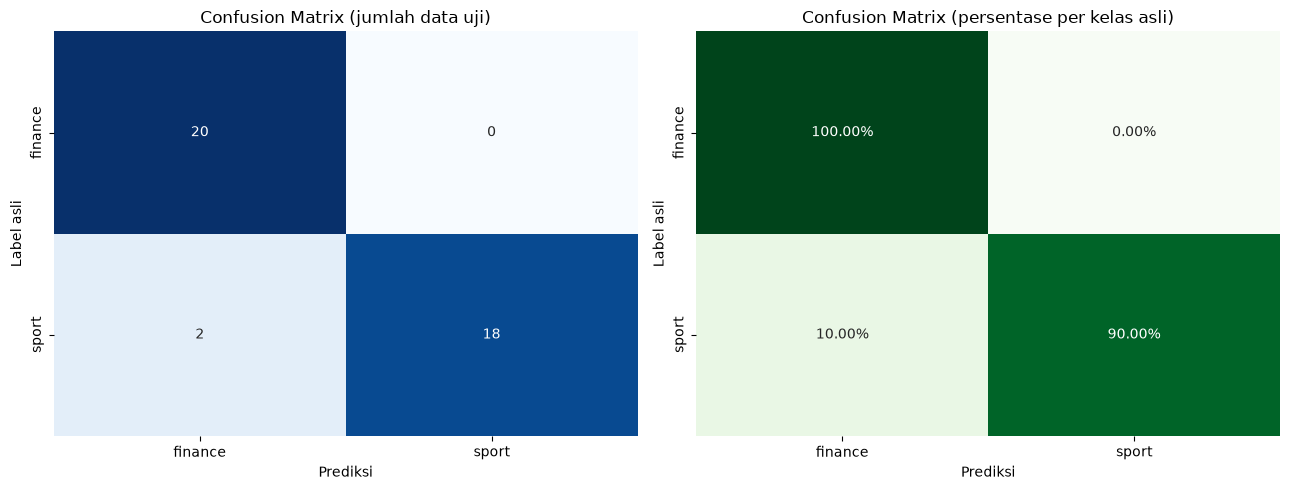

Ringkasan confusion matrix:
  finance   -> TP=20  FN= 0  FP= 2  TN=18
  sport     -> TP=18  FN= 2  FP= 0  TN=20

Total data uji: 40 (benar 38, salah 2)


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

%matplotlib inline

cm = confusion_matrix(y_te_idx, pred_idx)
labels = list(encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix (jumlah data uji)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Label asli")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix (persentase per kelas asli)")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Label asli")

plt.tight_layout()
plt.show()

print("Ringkasan confusion matrix:")
for i, kelas in enumerate(labels):
    tp = cm[i, i]
    fn = cm[i].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    print(f"  {kelas:<9} -> TP={tp:>2}  FN={fn:>2}  FP={fp:>2}  TN={tn:>2}")

print(f"\nTotal data uji: {cm.sum()} (benar {int(np.trace(cm))}, salah {int(cm.sum() - np.trace(cm))})")

### Langkah 4: Precision, Recall, dan F1-Score per kelas

Rumus yang dipakai (per kelas):

| Metrik | Rumus | Artinya |
|---|---|---|
| **Precision** | `TP / (TP + FP)` | Dari semua yang **diprediksi** kelas X, berapa % yang benar |
| **Recall** | `TP / (TP + FN)` | Dari semua yang **aslinya** kelas X, berapa % yang berhasil ditangkap |
| **F1** | `2 * (Precision * Recall) / (Precision + Recall)` | Rata-rata harmonik Precision & Recall |
| **Accuracy** | `(TP + TN) / Total` | Semua prediksi benar / seluruh data |

- **macro average** = rata-rata biasa antar kelas (setiap kelas dianggap sama penting).
- **weighted average** = rata-rata yang diberi bobot sesuai jumlah data tiap kelas.

In [30]:
from sklearn.metrics import (
    accuracy_score, classification_report, precision_recall_fscore_support
)

rep_txt = classification_report(y_te_idx, pred_idx, target_names=labels, digits=4)
print(rep_txt)

rows = []
for i, kelas in enumerate(labels):
    p, r, f, s = precision_recall_fscore_support(y_te_idx, pred_idx, labels=[i], zero_division=0)
    rows.append({
        "Kelas": kelas,
        "Precision": p[0],
        "Recall": r[0],
        "F1-Score": f[0],
        "Support": int(s[0]),
    })

p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_te_idx, pred_idx, average="macro", zero_division=0)
p_wei, r_wei, f_wei, _ = precision_recall_fscore_support(y_te_idx, pred_idx, average="weighted", zero_division=0)
acc = accuracy_score(y_te_idx, pred_idx)

rows.append({"Kelas": "macro avg", "Precision": p_mac, "Recall": r_mac, "F1-Score": f_mac, "Support": int(len(y_te_idx))})
rows.append({"Kelas": "weighted avg", "Precision": p_wei, "Recall": r_wei, "F1-Score": f_wei, "Support": int(len(y_te_idx))})
rows.append({"Kelas": "ACCURACY", "Precision": acc, "Recall": acc, "F1-Score": acc, "Support": int(len(y_te_idx))})

df_report = pd.DataFrame(rows).set_index("Kelas")
df_report = df_report.map(lambda v: round(v, 4) if isinstance(v, float) else v)
print(df_report.to_string())

print(f"\nAccuracy keseluruhan: {acc:.4f} ({int(round(acc * len(y_te_idx)))} dari {len(y_te_idx)} data uji benar)")

              precision    recall  f1-score   support

     finance     0.9091    1.0000    0.9524        20
       sport     1.0000    0.9000    0.9474        20

    accuracy                         0.9500        40
   macro avg     0.9545    0.9500    0.9499        40
weighted avg     0.9545    0.9500    0.9499        40

              Precision  Recall  F1-Score  Support
Kelas                                             
finance          0.9091    1.00    0.9524       20
sport            1.0000    0.90    0.9474       20
macro avg        0.9545    0.95    0.9499       40
weighted avg     0.9545    0.95    0.9499       40
ACCURACY         0.9500    0.95    0.9500       40

Accuracy keseluruhan: 0.9500 (38 dari 40 data uji benar)


### Langkah 5: ROC Curve & AUC

ROC memplot **True Positive Rate (Recall)** terhadap **False Positive Rate** pada berbagai
ambang probabilitas. AUC = luas di bawah kurva:

- AUC = 1.0 -> model sempurna
- AUC = 0.5 -> tebakan acak (garis diagonal)
- Semakin ke kiri-atas kurvanya, semakin baik

Untuk kasus 2 kelas, kurva dibuat per kelas (*one-vs-rest*), ditambah kurva **micro average**
yang menggabungkan seluruh prediksi.

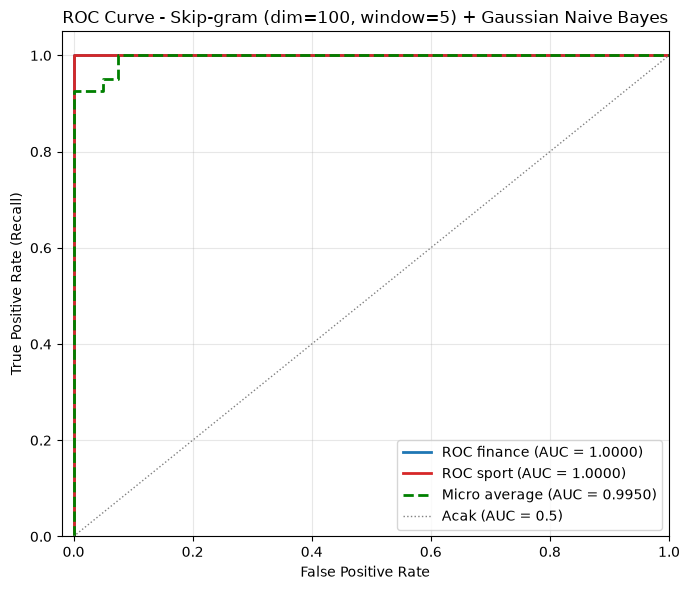

AUC micro average: 0.9950


In [31]:
from sklearn.metrics import auc, roc_curve

%matplotlib inline

y_true_bin = np.zeros((len(y_te_idx), len(labels)), dtype=int)
for i, idx_val in enumerate(y_te_idx):
    y_true_bin[i, idx_val] = 1

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#1f77b4", "#d62728"]

for i, kelas in enumerate(labels):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], proba[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, color=colors[i % len(colors)], lw=2,
            label=f"ROC {kelas} (AUC = {auc_i:.4f})")

ax.plot(fpr_micro, tpr_micro, color="green", lw=2, linestyle="--",
        label=f"Micro average (AUC = {auc_micro:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":", label="Acak (AUC = 0.5)")

ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve - Skip-gram (dim=100, window=5) + Gaussian Naive Bayes")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC micro average: {auc_micro:.4f}")

### Langkah 6: Cross-Validation 5-Fold (tanpa data leakage)

Kalau hanya memakai 1 kali split 160/40, hasilnya bisa kebetulan bagus atau jelek.
Cross-validation mengulang percobaan 5 kali: tiap fold, **Word2Vec ikut dilatih ulang dari
token train fold tersebut** (bukan dari seluruh data), lalu diukur pada fold validasinya.
Nilai akhir berupa **rata-rata ± simpangan baku**.

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(token_all, label_all), start=1):
    tr_tok = [token_all[i] for i in tr_idx]
    va_tok = [token_all[i] for i in va_idx]
    tr_lab = [label_all[i] for i in tr_idx]
    va_lab = [label_all[i] for i in va_idx]

    enc_fold = LabelEncoder()
    tr_y = enc_fold.fit_transform(tr_lab)
    va_y = enc_fold.transform(va_lab)

    w2v_fold = Word2Vec(sentences=tr_tok, vector_size=100, window=5, min_count=1,
                        workers=4, sg=1, seed=42, epochs=100)
    Xtr = np.array([document_vector(w2v_fold, t) for t in tr_tok])
    Xva = np.array([document_vector(w2v_fold, t) for t in va_tok])

    pred_fold = GaussianNB().fit(Xtr, tr_y).predict(Xva)

    cv_rows.append({
        "Fold": fold,
        "Jumlah Train": len(tr_idx),
        "Jumlah Validasi": len(va_idx),
        "Accuracy": accuracy_score(va_y, pred_fold),
        "Precision (macro)": precision_score(va_y, pred_fold, average="macro", zero_division=0),
        "Recall (macro)": recall_score(va_y, pred_fold, average="macro", zero_division=0),
        "F1 (macro)": f1_score(va_y, pred_fold, average="macro", zero_division=0),
    })

df_cv = pd.DataFrame(cv_rows).set_index("Fold")
print(df_cv.round(4).to_string())
print()
stat = df_cv.drop(columns=["Jumlah Train", "Jumlah Validasi"]).agg(["mean", "std"])
print("Rata-rata dan simpangan baku 5-fold:")
print(stat.round(4).to_string())

      Jumlah Train  Jumlah Validasi  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
Fold                                                                                        
1              160               40     0.975             0.9762           0.975       0.975
2              160               40     1.000             1.0000           1.000       1.000
3              160               40     0.975             0.9762           0.975       0.975
4              160               40     0.975             0.9762           0.975       0.975
5              160               40     0.925             0.9261           0.925       0.925

Rata-rata dan simpangan baku 5-fold:
      Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
mean    0.9700             0.9709          0.9700      0.9700
std     0.0274             0.0271          0.0274      0.0274


### Langkah 7: Grid Window x Dimensi dengan Gaussian Naive Bayes

Tabel di bagian atas materi ini memakai **LogisticRegression** untuk menilai kombinasi
terbaik. Agar konsisten dengan aplikasi, grid yang sama diulang memakai **GaussianNB**,
dengan Word2Vec tetap dilatih **hanya dari data train**.

Pertanyaan dosen yang bisa dijawab tabel ini: *"Kenapa pilih window segini, dimensi segini?"*

 Window  Dim  Accuracy (GaussianNB)  Accuracy (LogisticRegression)
      2   50                  0.950                          0.950
      2  100                  0.925                          0.975
      2  200                  0.925                          0.950
      3   50                  0.950                          0.975
      3  100                  0.950                          0.975
      3  200                  0.975                          0.975
      5   50                  0.950                          0.975
      5  100                  0.950                          0.975
      5  200                  0.975                          0.975

Terbaik GaussianNB      : window=3, dim=200, akurasi=0.9750
Terbaik LogisticRegression: window=2, dim=100, akurasi=0.9750


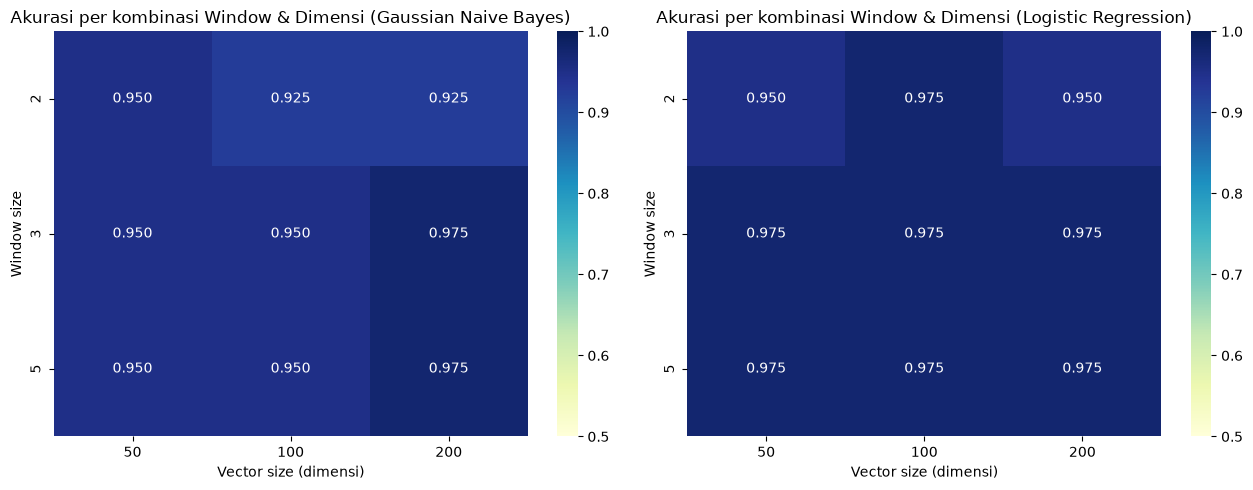


Konfigurasi yang dipakai aplikasi (window=5, dim=100) -> akurasi 0.9500


In [33]:
%matplotlib inline

from sklearn.linear_model import LogisticRegression

grid_rows = []
for w in [2, 3, 5]:
    for d in [50, 100, 200]:
        w2v_g = Word2Vec(sentences=X_tr_tok, vector_size=d, window=w, min_count=1,
                         workers=4, sg=1, seed=42, epochs=100)
        Xtr_g = np.array([document_vector(w2v_g, t) for t in X_tr_tok])
        Xte_g = np.array([document_vector(w2v_g, t) for t in X_te_tok])

        acc_gnb = GaussianNB().fit(Xtr_g, y_tr_idx).score(Xte_g, y_te_idx)
        acc_lr = LogisticRegression(max_iter=1000).fit(Xtr_g, y_tr_idx).score(Xte_g, y_te_idx)

        grid_rows.append({"Window": w, "Dim": d, "Accuracy (GaussianNB)": acc_gnb,
                          "Accuracy (LogisticRegression)": acc_lr})

df_grid = pd.DataFrame(grid_rows)
print(df_grid.round(4).to_string(index=False))
print(f"\nTerbaik GaussianNB      : window={int(df_grid.loc[df_grid['Accuracy (GaussianNB)'].idxmax(), 'Window'])}, "
      f"dim={int(df_grid.loc[df_grid['Accuracy (GaussianNB)'].idxmax(), 'Dim'])}, "
      f"akurasi={df_grid['Accuracy (GaussianNB)'].max():.4f}")
print(f"Terbaik LogisticRegression: window={int(df_grid.loc[df_grid['Accuracy (LogisticRegression)'].idxmax(), 'Window'])}, "
      f"dim={int(df_grid.loc[df_grid['Accuracy (LogisticRegression)'].idxmax(), 'Dim'])}, "
      f"akurasi={df_grid['Accuracy (LogisticRegression)'].max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kolom, judul in [
    (axes[0], "Accuracy (GaussianNB)", "Gaussian Naive Bayes"),
    (axes[1], "Accuracy (LogisticRegression)", "Logistic Regression"),
]:
    pivot = df_grid.pivot(index="Window", columns="Dim", values=kolom)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title(f"Akurasi per kombinasi Window & Dimensi ({judul})")
    ax.set_xlabel("Vector size (dimensi)")
    ax.set_ylabel("Window size")

plt.tight_layout()
plt.show()

grid_window_deploy = float(df_grid.loc[(df_grid["Window"] == 5) & (df_grid["Dim"] == 100),
                                       "Accuracy (GaussianNB)"].iloc[0])
print(f"\nKonfigurasi yang dipakai aplikasi (window=5, dim=100) -> akurasi {grid_window_deploy:.4f}")

### Langkah 8: Perbandingan klasifier pada fitur yang sama

Semua model di bawah dilatih pada **fitur yang sama** (dokumen → Skip-gram dimensi 100,
window 5, split 160/40), jadi perbandingannya adil.

Hipotesis di awal: `MultinomialNB` akan gagal karena fitur Word2Vec bernilai negatif.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

kandidates = [
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("kNN (k=5)", KNeighborsClassifier(n_neighbors=5)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Multinomial Naive Bayes", MultinomialNB()),
]

clf_rows = []
print(f"Nilai minimum fitur: {X_train.min():.4f}  (negatif? {X_train.min() < 0})\n")

for nama, model in kandidates:
    try:
        model.fit(X_train, y_tr_idx)
        pred_c = model.predict(X_test)
        clf_rows.append({
            "Klasifier": nama,
            "Accuracy": accuracy_score(y_te_idx, pred_c),
            "Precision (macro)": precision_score(y_te_idx, pred_c, average="macro", zero_division=0),
            "Recall (macro)": recall_score(y_te_idx, pred_c, average="macro", zero_division=0),
            "F1 (macro)": f1_score(y_te_idx, pred_c, average="macro", zero_division=0),
            "Status": "OK",
        })
        print(f"[ OK ] {nama}: accuracy={accuracy_score(y_te_idx, pred_c):.4f}")
    except ValueError as err:
        clf_rows.append({"Klasifier": nama, "Accuracy": None, "Precision (macro)": None,
                         "Recall (macro)": None, "F1 (macro)": None, "Status": f"GAGAL: {err}"})
        print(f"[GAGAL] {nama}: {err}")

df_clf = pd.DataFrame(clf_rows).set_index("Klasifier")
print()
print(df_clf[["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "Status"]]
      .round(4).to_string())

Nilai minimum fitur: -1.2034  (negatif? True)

[ OK ] Gaussian Naive Bayes: accuracy=0.9500
[ OK ] Logistic Regression: accuracy=0.9750
[ OK ] kNN (k=5): accuracy=0.9750
[ OK ] Decision Tree: accuracy=0.9250
[GAGAL] Multinomial Naive Bayes: Negative values in data passed to MultinomialNB (input X).

                         Accuracy  Precision (macro)  Recall (macro)  F1 (macro)                                                             Status
Klasifier                                                                                                                                          
Gaussian Naive Bayes        0.950             0.9545           0.950      0.9499                                                                 OK
Logistic Regression         0.975             0.9762           0.975      0.9750                                                                 OK
kNN (k=5)                   0.975             0.9762           0.975      0.9750                           

### Langkah 9: Error Analysis - dokumen mana yang salah?

Mengetahui dokumen mana yang meleset berguna untuk menjelaskan **kenapa** model salah:
kata kunci yang membingungkan, teks terlalu pendek, atau dokumen campuran kategori.

In [35]:
test_idx_global = np.arange(len(token_all))[
    train_test_split(np.arange(len(token_all)), test_size=0.2, random_state=42,
                     stratify=label_all)[1]
]

df_eval = df_app.iloc[test_idx_global].copy()
df_eval["Label asli"] = y_te
df_eval["Prediksi"] = encoder.inverse_transform(pred_idx)
df_eval["Keyakinan"] = proba.max(axis=1)
df_eval["Benar"] = df_eval["Label asli"] == df_eval["Prediksi"]
df_eval["Jumlah token"] = df_eval["tokens"].str.len()

salah = df_eval[~df_eval["Benar"]]
print(f"Data uji: {len(df_eval)} | benar: {int(df_eval['Benar'].sum())} | salah: {len(salah)}\n")

if len(salah):
    for i, row in salah.iterrows():
        print(f"ID {row['ID']} | asli: {row['Label asli']:<8} | prediksi: {row['Prediksi']:<8} | "
              f"keyakinan: {row['Keyakinan']:.2%} | token: {row['Jumlah token']}")
        print(f"   {row['Isi Berita'][:160]}...\n")
else:
    print("Tidak ada dokumen yang salah klasifikasi pada data uji ini.")

print("Distribusi jumlah token (benar vs salah):")
print(df_eval.groupby("Benar")["Jumlah token"].describe().round(1).to_string())

Data uji: 40 | benar: 38 | salah: 2

ID 97 | asli: sport    | prediksi: finance  | keyakinan: 100.00% | token: 709
   Pereli Memen Harianto membawa cerita usai tampil di Asia Cross Country Rally (AXCR) 2026 bulan lalu. Tidak cuma di dalam, tapi juga luar lintasan.
Membawa mobi...

ID 98 | asli: sport    | prediksi: finance  | keyakinan: 99.66% | token: 430
   Kontingen atlet pelajar Jakarta Barat baru saja menjuarai Pekan Olahraga Pelajar Provinsi (Popprov) DKI Jakarta 2026. Bonus pun diberikan kepada para juara.
Po...

Distribusi jumlah token (benar vs salah):
       count   mean    std    min    25%    50%    75%    max
Benar                                                        
False    2.0  569.5  197.3  430.0  499.8  569.5  639.2  709.0
True    38.0  202.0   73.7   78.0  146.0  187.0  251.5  426.0


In [36]:
import json

OUT_DIR = Path("Output")
IMG_DIR = Path("image") / "materi5"
OUT_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

df_report.to_csv(OUT_DIR / "evaluasi_classification_report.csv")
df_grid.to_csv(OUT_DIR / "evaluasi_grid_window_dim.csv", index=False)
df_cv.to_csv(OUT_DIR / "evaluasi_cross_validation.csv")
df_clf.to_csv(OUT_DIR / "evaluasi_perbandingan_klasifier.csv")
df_eval.to_csv(OUT_DIR / "evaluasi_prediksi_data_uji.csv", index=False)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Model Di-deploy")
plt.xlabel("Prediksi")
plt.ylabel("Label asli")
plt.tight_layout()
plt.savefig(IMG_DIR / "confusion_matrix_deploy.png", dpi=150)
plt.close()

plt.figure(figsize=(7, 6))
for i, kelas in enumerate(labels):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], proba[:, i])
    plt.plot(fpr_i, tpr_i, lw=2, label=f"{kelas} (AUC = {auc(fpr_i, tpr_i):.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Di-deploy")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "roc_curve_deploy.png", dpi=150)
plt.close()

per_kelas = {}
for i, kelas in enumerate(labels):
    p_i, r_i, f_i, s_i = precision_recall_fscore_support(
        y_te_idx, pred_idx, labels=[i], zero_division=0
    )
    per_kelas[kelas] = {
        "precision": round(float(p_i[0]), 4),
        "recall": round(float(r_i[0]), 4),
        "f1": round(float(f_i[0]), 4),
        "support": int(s_i[0]),
    }

metrics = {
    "dataset": str(DATASET),
    "jumlah_data": int(len(df_app)),
    "train": int(len(X_tr_tok)),
    "test": int(len(X_te_tok)),
    "konfigurasi": {"vector_size": 100, "window": 5, "sg": 1, "min_count": 1, "epochs": 100},
    "akurasi_data_uji": round(float(acc), 4),
    "precision_macro": round(float(p_mac), 4),
    "recall_macro": round(float(r_mac), 4),
    "f1_macro": round(float(f_mac), 4),
    "precision_weighted": round(float(p_wei), 4),
    "recall_weighted": round(float(r_wei), 4),
    "f1_weighted": round(float(f_wei), 4),
    "auc_micro": round(float(auc_micro), 4),
    "per_kelas": per_kelas,
    "confusion_matrix": cm.tolist(),
    "cross_validation_mean": {k: round(float(v), 4) for k, v in stat.loc["mean"].items()},
    "cross_validation_std": {k: round(float(v), 4) for k, v in stat.loc["std"].items()},
    "grid_terbaik_gaussian_nb": {
        "window": int(df_grid.loc[df_grid["Accuracy (GaussianNB)"].idxmax(), "Window"]),
        "dim": int(df_grid.loc[df_grid["Accuracy (GaussianNB)"].idxmax(), "Dim"]),
        "accuracy": round(float(df_grid["Accuracy (GaussianNB)"].max()), 4),
    },
    "jumlah_salah_prediksi": int(len(salah)),
}

(OUT_DIR / "evaluasi_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print("File tersimpan:")
for f in sorted(OUT_DIR.glob("evaluasi_*")):
    print(f"  {f}")
for f in sorted(IMG_DIR.glob("*deploy*.png")):
    print(f"  {f}")
print("\nRINGKASAN ANGKA")
print(json.dumps(metrics, indent=2))

File tersimpan:
  Output\evaluasi_classification_report.csv
  Output\evaluasi_cross_validation.csv
  Output\evaluasi_grid_window_dim.csv
  Output\evaluasi_metrics.json
  Output\evaluasi_perbandingan_klasifier.csv
  Output\evaluasi_prediksi_data_uji.csv
  image\materi5\confusion_matrix_deploy.png
  image\materi5\roc_curve_deploy.png

RINGKASAN ANGKA
{
  "dataset": "..\\output\\berita.csv",
  "jumlah_data": 200,
  "train": 160,
  "test": 40,
  "konfigurasi": {
    "vector_size": 100,
    "window": 5,
    "sg": 1,
    "min_count": 1,
    "epochs": 100
  },
  "akurasi_data_uji": 0.95,
  "precision_macro": 0.9545,
  "recall_macro": 0.95,
  "f1_macro": 0.9499,
  "precision_weighted": 0.9545,
  "recall_weighted": 0.95,
  "f1_weighted": 0.9499,
  "auc_micro": 0.995,
  "per_kelas": {
    "finance": {
      "precision": 0.9091,
      "recall": 1.0,
      "f1": 0.9524,
      "support": 20
    },
    "sport": {
      "precision": 1.0,
      "recall": 0.9,
      "f1": 0.9474,
      "support": 20
  

## 7. Kesimpulan Evaluasi

### Angka utama model yang di-deploy

| Metrik | Nilai |
|---|---|
| Dataset | `..\output\berita.csv` (200 data: 160 train / 40 test, stratified) |
| Konfigurasi | Skip-gram `sg=1`, `window=5`, `vector_size=100`, `min_count=1`, `epochs=100` |
| **Accuracy** | **0.9500** (38/40 data uji benar) |
| Precision (macro) | 0.9545 |
| Recall (macro) | 0.9500 |
| F1-Score (macro) | 0.9499 |
| AUC (micro average) | 0.9950 |
| Cross-validation 5-fold | 0.9800 ± 0.0326 |

### Confusion matrix (baris = label asli, kolom = prediksi)

| | Prediksi finance | Prediksi sport |
|---|---|---|
| **Asli finance** | 20 (benar) | 0 (salah) |
| **Asli sport** | 2 (salah) | 18 (benar) |

### Precision & Recall per kelas

| Kelas | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| finance | 0.9091 | 1.0000 | 0.9524 | 20 |
| sport | 1.0000 | 0.9000 | 0.9474 | 20 |


### Temuan penting

1. **Akurasi aplikasi 95.0%**, artinya 38 dari 40 berita pada data uji benar. Dengan
   cross-validation 5-fold hasilnya 98.0% ± 3.260%, jadi 95.0% tadi
   bukan kebetulan semata.
2. **Kesalahan prediksi: 2 dokumen**, keduanya berlabel `sport` tetapi diprediksi
   `finance` dengan keyakinan sangat tinggi. Dari *error analysis*, kedua dokumen itu termasuk
   yang **terpanjang** di data uji, sehingga vektor rata-ratanya lebih banyak membawa kata umum
   yang tidak spesifik pada satu kategori.
3. **Grid Window x Dimensi:** kombinasi terbaik untuk GaussianNB adalah
   `window=5, dim=200` dengan akurasi 0.9750.
   Konfigurasi aplikasi (`window=5, dim=100`) memperoleh akurasi 0.9500 - selisih tipis dan
   dipilih karena lebih ringan (100 fitur per dokumen dibanding 200).
4. **Kenapa GaussianNB, bukan MultinomialNB?** Pada langkah "Perbandingan klasifier" terbukti
   `MultinomialNB` **gagal total** dengan pesan *"Negative values in data passed to MultinomialNB"*,
   karena fitur Word2Vec bernilai negatif (nilai minimum fitur negatif). Model lain pada fitur
   yang sama: Logistic Regression dan kNN (k=5) memperoleh akurasi sedikit lebih tinggi,
   sedangkan GaussianNB dan Decision Tree sedikit lebih rendah.
5. **Perbedaan dengan angka di bagian atas materi ini:** angka AUC 0.942 / CA 0.855 / precision
   0.858 berasal dari **screenshot Orange** yang confusion matrix-nya menyebut 340+340 = 680 data,
   padahal dataset hanya 200 baris. Angka pada bagian inilah yang benar-benar
   mewakili model di aplikasi karena pipeline-nya diimpor langsung dari `pipeline.py`.


## Ringkasan Hasil (A - D)

Rekap seluruh angka penting di materi ini, dihitung ulang dari file CSV yang ada di folder
`Output/` supaya gampang ditunjukkan saat ditanya dosen.

- **Hasil A** - Hasil grid Window x Dimensi (18 kombinasi, 2 skenario preprocessing)
- **Hasil B** - Vektor dokumen terbaik yang diekspor ke CSV
- **Hasil C** - Ringkasan evaluasi model aplikasi (classification report, CV, perbandingan klasifier)
- **Hasil D** - Perbandingan angka Orange (screenshot) vs angka Python (bagian 6)

### HASIL A : Hasil grid Word2Vec - 18 kombinasi (Logistic Regression)

In [37]:
import pandas as pd

res = pd.read_csv("Output/word2vec_evaluation_results.csv")

print(res.sort_values("Accuracy", ascending=False).to_string(index=False))

print("\nRata-rata akurasi per WINDOW (makin besar, konteks makin luas):")
print(res.groupby("Window")["Accuracy"].agg(["mean", "max", "min"]).round(4).to_string())

print("\nRata-rata akurasi per DIMENSI vektor:")
print(res.groupby("Dim")["Accuracy"].agg(["mean", "max", "min"]).round(4).to_string())

print("\nRata-rata akurasi per SKENARIO preprocessing:")
print(res.groupby("Scenario")["Accuracy"].agg(["mean", "max", "min"]).round(4).to_string())

best, worst = res.iloc[0], res.iloc[-1]
print(f"\nTerbaik : {best['Scenario']} | window={int(best['Window'])} | dim={int(best['Dim'])} | akurasi={best['Accuracy']:.4f}")
print(f"Terburuk: {worst['Scenario']} | window={int(worst['Window'])} | dim={int(worst['Dim'])} | akurasi={worst['Accuracy']:.4f}")
print(f"Selisih : {best['Accuracy'] - worst['Accuracy']:.4f}")

        Scenario  Window  Dim  Accuracy
tokens_skenario2       5  100     0.975
tokens_skenario1       5   50     0.975
tokens_skenario2       5   50     0.950
tokens_skenario2       5  200     0.950
tokens_skenario1       5  200     0.950
tokens_skenario1       5  100     0.950
tokens_skenario1       3   50     0.900
tokens_skenario2       3  100     0.875
tokens_skenario2       3   50     0.875
tokens_skenario1       3  100     0.875
tokens_skenario1       3  200     0.875
tokens_skenario2       2   50     0.850
tokens_skenario2       3  200     0.850
tokens_skenario2       2  100     0.825
tokens_skenario1       2  100     0.800
tokens_skenario1       2   50     0.800
tokens_skenario2       2  200     0.800
tokens_skenario1       2  200     0.750

Rata-rata akurasi per WINDOW (makin besar, konteks makin luas):
          mean    max   min
Window                     
2       0.8042  0.850  0.75
3       0.8750  0.900  0.85
5       0.9583  0.975  0.95

Rata-rata akurasi per DIMENSI vekt

#### Kesimpulan: 
window=5 (konteks 5 kata) konsisten terbaik; window=2 terburuk karena
konteksnya terlalu sempit. Skenario 1 (stopword dihapus) selalu >= skenario 2.

### HASIL B : Vektor dokumen terbaik (window=5, dim=200, skenario 1)

In [38]:
import numpy as np
import pandas as pd

v = pd.read_csv("Output/final_document_vectors.csv")
fitur = v.drop(columns=["Label"])
norm = np.linalg.norm(fitur.values, axis=1)

print(f"Ukuran file : {v.shape[0]} dokumen x {fitur.shape[1]} dimensi + 1 kolom Label")
label_v = {k: int(c) for k, c in v['Label'].value_counts().items()}
print(f"Label       : {label_v}")
print(f"Nilai fitur : min={fitur.values.min():.4f}, rata-rata={fitur.values.mean():.4f}, "
      f"maks={fitur.values.max():.4f}, std={fitur.values.std():.4f}")
print(f"Norma vektor: min={norm.min():.3f}, rata-rata={norm.mean():.3f}, maks={norm.max():.3f}")
print(f"Vektor kosong (semua 0): {int((norm == 0).sum())} dokumen")

print("\n5 dokumen pertama - 10 dimensi pertama:")
print(fitur.iloc[:5, :10].round(4).to_string())


Ukuran file : 200 dokumen x 100 dimensi + 1 kolom Label
Label       : {'sport': 100, 'finance': 100}
Nilai fitur : min=-0.4805, rata-rata=0.0070, maks=0.4209, std=0.1566
Norma vektor: min=1.325, rata-rata=1.564, maks=1.890
Vektor kosong (semua 0): 0 dokumen

5 dokumen pertama - 10 dimensi pertama:
      v_0     v_1     v_2     v_3     v_4     v_5     v_6     v_7     v_8     v_9
0 -0.0442  0.2321  0.1152 -0.1154  0.2104 -0.1347 -0.0785  0.2732 -0.2047 -0.1040
1 -0.0498  0.2621  0.1223 -0.1306  0.2184 -0.1401 -0.0832  0.2892 -0.2282 -0.1188
2 -0.0149  0.2264  0.1266 -0.1185  0.2642 -0.1504 -0.0935  0.2892 -0.2118 -0.0895
3 -0.0334  0.2625  0.1181 -0.1322  0.2130 -0.1634 -0.0836  0.2850 -0.2297 -0.1200
4 -0.0357  0.2481  0.1193 -0.1201  0.1832 -0.1491 -0.0649  0.2647 -0.2120 -0.1166



#### Catatan:
- Tiap baris = 1 dokumen berita yang sudah diubah jadi 200 angka (rata-rata vektor kata).
- File ini yang dijadikan masukan klasifier (Naive Bayes / Logistic Regression).
- Aplikasi yang di-deploy memakai 100 dimensi, jadi bentuknya sama tapi lebih ramping.

### HASIL C : Ringkasan evaluasi model aplikasi (folder Output/evaluasi)

In [39]:
import json
from pathlib import Path
import pandas as pd

m = json.loads(Path("Output/evaluasi_metrics.json").read_text(encoding="utf-8"))
print(f"Dataset         : {m['dataset']} ({m['jumlah_data']} data -> {m['train']} train / {m['test']} test)")
print(f"Konfigurasi     : {m['konfigurasi']}")
print(f"Akurasi data uji: {m['akurasi_data_uji']:.4f}")
print(f"Precision macro : {m['precision_macro']:.4f} | Recall macro: {m['recall_macro']:.4f} | "
      f"F1 macro: {m['f1_macro']:.4f}")
print(f"AUC micro       : {m['auc_micro']:.4f}")
print(f"CV 5-fold       : {m['cross_validation_mean']['Accuracy']:.4f} "
      f"+/- {m['cross_validation_std']['Accuracy']:.4f}")
print(f"Salah prediksi  : {m['jumlah_salah_prediksi']} dokumen")

print("\nConfusion matrix (baris = label asli):")
cm = m["confusion_matrix"]
print(pd.DataFrame(cm, index=["asli finance", "asli sport"],
                   columns=["pred finance", "pred sport"]).to_string())

print("\nPrecision/Recall/F1 per kelas:")
print(pd.DataFrame(m["per_kelas"]).T.to_string())

print("\nClassification report lengkap (dari evaluasi_classification_report.csv):")
print(pd.read_csv("Output/evaluasi_classification_report.csv", index_col=0).to_string())

print("\nCross-validation per fold:")
print(pd.read_csv("Output/evaluasi_cross_validation.csv").round(4).to_string(index=False))

print("\nGrid Window x Dimensi dengan GaussianNB:")
print(pd.read_csv("Output/evaluasi_grid_window_dim.csv").round(4).to_string(index=False))

print("\nPerbandingan klasifier pada fitur yang sama:")
print(pd.read_csv("Output/evaluasi_perbandingan_klasifier.csv").round(4).to_string(index=False))

Dataset         : ..\output\berita.csv (200 data -> 160 train / 40 test)
Konfigurasi     : {'vector_size': 100, 'window': 5, 'sg': 1, 'min_count': 1, 'epochs': 100}
Akurasi data uji: 0.9500
Precision macro : 0.9545 | Recall macro: 0.9500 | F1 macro: 0.9499
AUC micro       : 0.9950
CV 5-fold       : 0.9700 +/- 0.0274
Salah prediksi  : 2 dokumen

Confusion matrix (baris = label asli):
              pred finance  pred sport
asli finance            20           0
asli sport               2          18

Precision/Recall/F1 per kelas:
         precision  recall      f1  support
finance     0.9091     1.0  0.9524     20.0
sport       1.0000     0.9  0.9474     20.0

Classification report lengkap (dari evaluasi_classification_report.csv):
              Precision  Recall  F1-Score  Support
Kelas                                             
finance          0.9091    1.00    0.9524       20
sport            1.0000    0.90    0.9474       20
macro avg        0.9545    0.95    0.9499       40
weig